# Практическая работа №5
## Полиномиальная регрессия и регуляризация
### Вариант №7

**Студент:** Ли Вадим  
**Группа:** __________________

## Цель работы

Исследовать поведение Ridge, Lasso и Elastic Net в трёх ситуациях:

1. анализ остатков и гомоскедастичности;
2. отбор признаков и доля ложных открытий FDR;
3. прогнозирование временного ряда по лаговым признакам.

# Задание 1. Ridge + Residual Analysis

После обучения Ridge на `fetch_california_housing` необходимо построить график остатков $y-\hat y$ относительно предсказаний $\hat y$ и сравнить гомоскедастичность с обычной `LinearRegression`.

Для сравнения дополнительно используется коэффициент вариации стандартных отклонений остатков по квантильным интервалам предсказаний. Чем он меньше, тем равномернее разброс ошибок.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing, make_regression
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

housing = fetch_california_housing(as_frame=True)
X_housing = housing.data
y_housing = housing.target

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing,
    y_housing,
    test_size=0.2,
    random_state=42
)

alphas_ridge = np.logspace(-4, 3, 80)

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=alphas_ridge, cv=5))
])

linear_model.fit(X_train_h, y_train_h)
ridge_model.fit(X_train_h, y_train_h)

pred_linear = linear_model.predict(X_test_h)
pred_ridge = ridge_model.predict(X_test_h)

res_linear = y_test_h.to_numpy() - pred_linear
res_ridge = y_test_h.to_numpy() - pred_ridge

ridge_alpha = ridge_model.named_steps["model"].alpha_

metrics_task1 = pd.DataFrame({
    "Model": ["LinearRegression", "Ridge"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_h, pred_linear)),
        np.sqrt(mean_squared_error(y_test_h, pred_ridge))
    ],
    "R2": [
        r2_score(y_test_h, pred_linear),
        r2_score(y_test_h, pred_ridge)
    ],
    "Mean residual": [
        np.mean(res_linear),
        np.mean(res_ridge)
    ]
})

display(metrics_task1)
print(f"Оптимальный alpha Ridge: {ridge_alpha:.6f}")

,Model,RMSE,R2,Mean residual
0,LinearRegression,0.745581,0.575788,0.003479
1,Ridge,0.745581,0.575788,0.003479


Оптимальный alpha Ridge: 0.000100


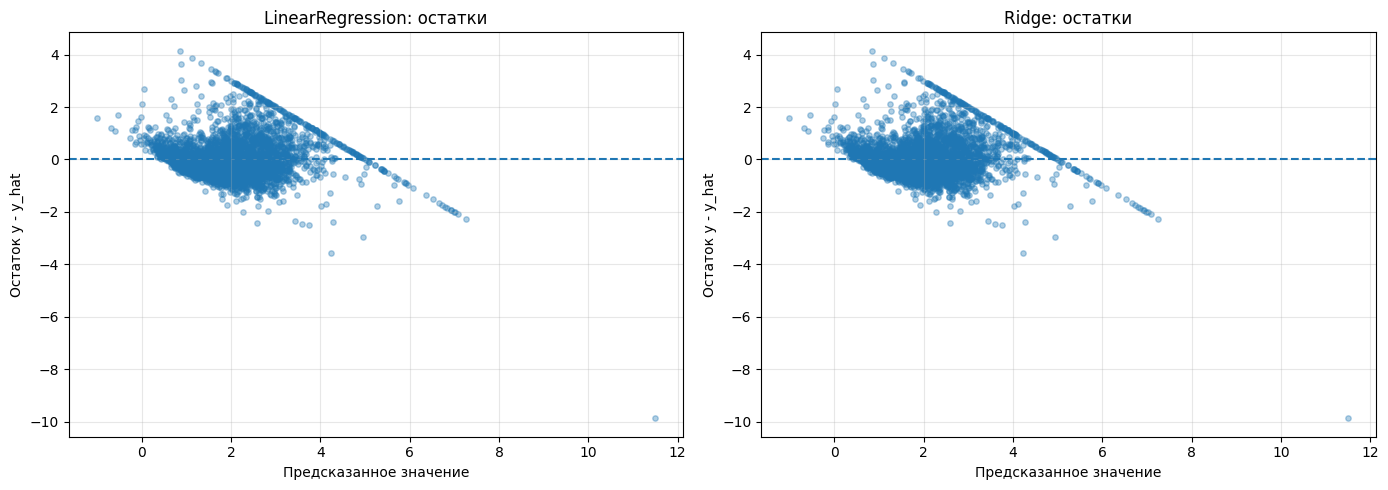

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(pred_linear, res_linear, alpha=0.35, s=15)
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Предсказанное значение")
axes[0].set_ylabel("Остаток y - y_hat")
axes[0].set_title("LinearRegression: остатки")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(pred_ridge, res_ridge, alpha=0.35, s=15)
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("Предсказанное значение")
axes[1].set_ylabel("Остаток y - y_hat")
axes[1].set_title("Ridge: остатки")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

,Model,Spread CV,"Corr(pred, |residual|)"
0,LinearRegression,0.230464,0.245192
1,Ridge,0.230464,0.245192


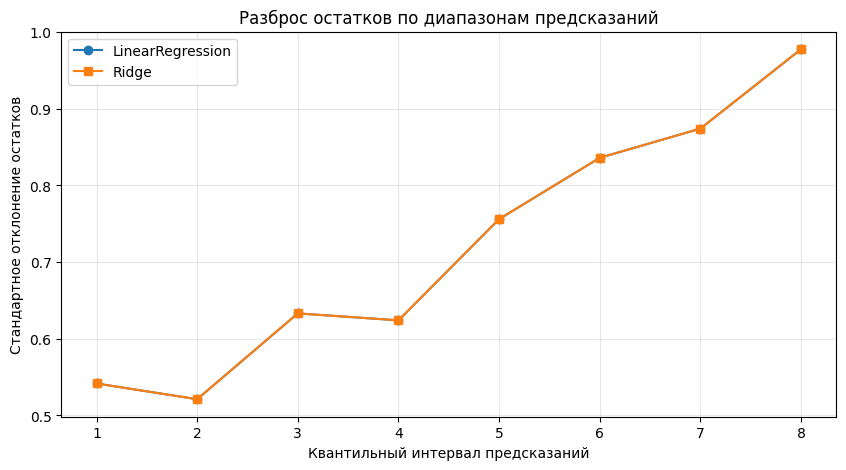

Показатели дают смешанный результат, поэтому однозначного улучшения гомоскедастичности нет.


In [3]:
def residual_spread_score(predicted, residuals, n_bins=8):
    frame = pd.DataFrame({
        "predicted": predicted,
        "residual": residuals
    })

    frame["bin"] = pd.qcut(
        frame["predicted"],
        q=n_bins,
        duplicates="drop"
    )

    spread = frame.groupby("bin", observed=True)["residual"].std()
    score = spread.std() / spread.mean()
    abs_corr = np.corrcoef(
        frame["predicted"],
        np.abs(frame["residual"])
    )[0, 1]

    return score, abs_corr, spread

linear_score, linear_abs_corr, linear_spread = residual_spread_score(
    pred_linear,
    res_linear
)

ridge_score, ridge_abs_corr, ridge_spread = residual_spread_score(
    pred_ridge,
    res_ridge
)

homoscedasticity_df = pd.DataFrame({
    "Model": ["LinearRegression", "Ridge"],
    "Spread CV": [linear_score, ridge_score],
    "Corr(pred, |residual|)": [linear_abs_corr, ridge_abs_corr]
})

display(homoscedasticity_df)

plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(linear_spread) + 1),
    linear_spread.values,
    marker="o",
    label="LinearRegression"
)
plt.plot(
    range(1, len(ridge_spread) + 1),
    ridge_spread.values,
    marker="s",
    label="Ridge"
)
plt.xlabel("Квантильный интервал предсказаний")
plt.ylabel("Стандартное отклонение остатков")
plt.title("Разброс остатков по диапазонам предсказаний")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

if ridge_score < linear_score and abs(ridge_abs_corr) < abs(linear_abs_corr):
    print("По двум используемым показателям Ridge улучшил гомоскедастичность.")
elif ridge_score > linear_score and abs(ridge_abs_corr) > abs(linear_abs_corr):
    print("По двум используемым показателям Ridge не улучшил гомоскедастичность.")
else:
    print("Показатели дают смешанный результат, поэтому однозначного улучшения гомоскедастичности нет.")

### Вывод по заданию 1

Регуляризация Ridge уменьшает чувствительность коэффициентов к мультиколлинеарности, но сама по себе не гарантирует устранение гетероскедастичности. Поэтому вывод делается не только по качеству модели, но и по форме облака остатков и по изменению разброса ошибок в разных диапазонах предсказаний.

Если у Ridge одновременно меньше `Spread CV` и меньше по модулю корреляция между прогнозом и абсолютным остатком, гомоскедастичность можно считать улучшившейся. Если показатели расходятся, корректнее говорить, что явного улучшения нет.

# Задание 2. Lasso + False Discovery Rate

Создадим задачу с большим числом признаков, где истинно информативные признаки известны заранее. Это позволяет посчитать долю ложных открытий:

$$FDR = \frac{FP}{TP + FP}$$

где `FP` — число ошибочно выбранных признаков, а `TP` — число правильно выбранных информативных признаков.

In [4]:
X_fdr, y_fdr, true_coef = make_regression(
    n_samples=400,
    n_features=100,
    n_informative=10,
    noise=20.0,
    coef=True,
    random_state=42
)

X_train_fdr, X_test_fdr, y_train_fdr, y_test_fdr = train_test_split(
    X_fdr,
    y_fdr,
    test_size=0.25,
    random_state=42
)

scaler_fdr = StandardScaler()
X_train_fdr_scaled = scaler_fdr.fit_transform(X_train_fdr)
X_test_fdr_scaled = scaler_fdr.transform(X_test_fdr)

true_features = set(
    np.flatnonzero(np.abs(true_coef) > 1e-12)
)

alpha_values = np.logspace(-3, 1.5, 18)
fdr_rows = []

for alpha in alpha_values:
    model = Lasso(
        alpha=alpha,
        max_iter=50000,
        random_state=42
    )

    model.fit(X_train_fdr_scaled, y_train_fdr)

    selected = set(
        np.flatnonzero(np.abs(model.coef_) > 1e-5)
    )

    tp = len(selected & true_features)
    fp = len(selected - true_features)
    fn = len(true_features - selected)

    fdr = fp / max(len(selected), 1)
    recall = tp / len(true_features)

    pred = model.predict(X_test_fdr_scaled)
    rmse = np.sqrt(mean_squared_error(y_test_fdr, pred))

    fdr_rows.append({
        "alpha": alpha,
        "selected": len(selected),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "FDR": fdr,
        "Recall": recall,
        "Test RMSE": rmse
    })

fdr_df = pd.DataFrame(fdr_rows)
display(fdr_df)

,alpha,selected,TP,FP,FN,FDR,Recall,Test RMSE
0,0.001000,100,10,90,0,0.900000,1.0,25.364242
1,0.001840,100,10,90,0,0.900000,1.0,25.357111
2,0.003384,100,10,90,0,0.900000,1.0,25.344284
3,0.006225,100,10,90,0,0.900000,1.0,25.320332
4,0.011450,99,10,89,0,0.898990,1.0,25.276527
5,0.021063,99,10,89,0,0.898990,1.0,25.199370
6,0.038747,97,10,87,0,0.896907,1.0,25.066442
7,0.071276,92,10,82,0,0.891304,1.0,24.878420
8,0.131113,89,10,79,0,0.887640,1.0,24.611827
9,0.241186,79,10,69,0,0.873418,1.0,24.202741


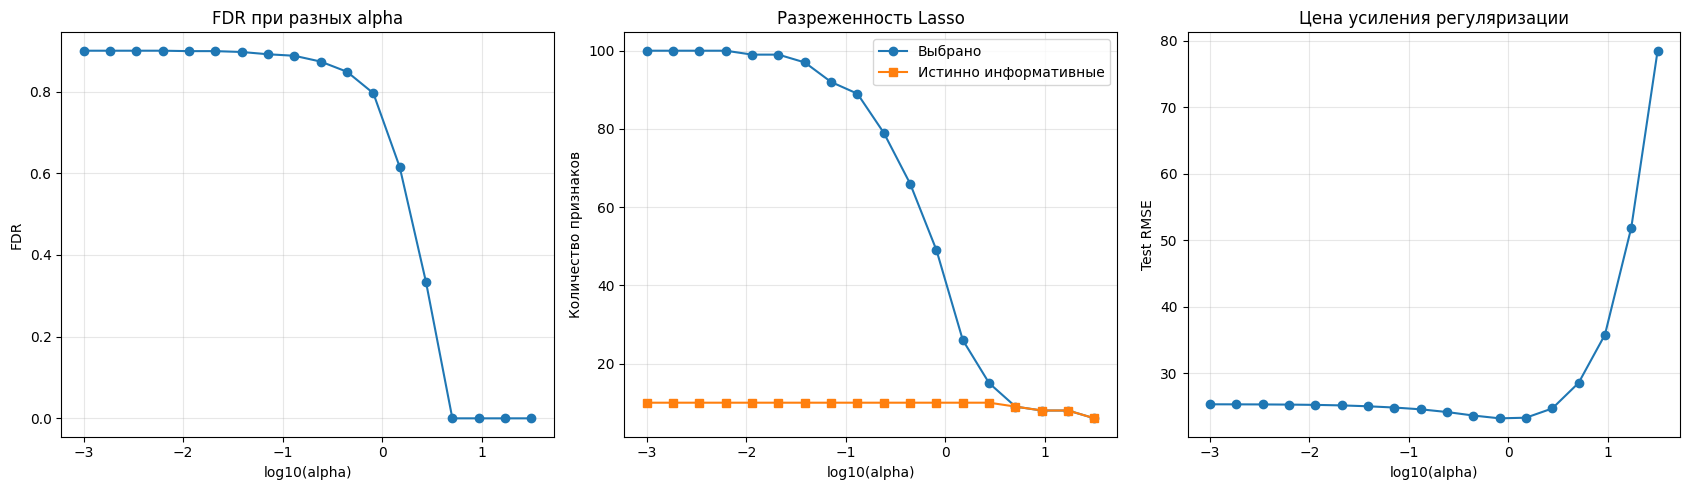

Минимальный Test RMSE достигается при alpha=0.816140: FDR=0.796, Recall=1.000
Минимальный FDR=0.000 достигается начиная примерно с alpha=5.080218


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(
    np.log10(fdr_df["alpha"]),
    fdr_df["FDR"],
    marker="o"
)
axes[0].set_xlabel("log10(alpha)")
axes[0].set_ylabel("FDR")
axes[0].set_title("FDR при разных alpha")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    np.log10(fdr_df["alpha"]),
    fdr_df["selected"],
    marker="o",
    label="Выбрано"
)
axes[1].plot(
    np.log10(fdr_df["alpha"]),
    fdr_df["TP"],
    marker="s",
    label="Истинно информативные"
)
axes[1].set_xlabel("log10(alpha)")
axes[1].set_ylabel("Количество признаков")
axes[1].set_title("Разреженность Lasso")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(
    np.log10(fdr_df["alpha"]),
    fdr_df["Test RMSE"],
    marker="o"
)
axes[2].set_xlabel("log10(alpha)")
axes[2].set_ylabel("Test RMSE")
axes[2].set_title("Цена усиления регуляризации")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_rmse_row = fdr_df.loc[fdr_df["Test RMSE"].idxmin()]
lowest_fdr_rows = fdr_df[fdr_df["FDR"] == fdr_df["FDR"].min()]

print(
    f"Минимальный Test RMSE достигается при alpha={best_rmse_row['alpha']:.6f}: "
    f"FDR={best_rmse_row['FDR']:.3f}, Recall={best_rmse_row['Recall']:.3f}"
)

print(
    f"Минимальный FDR={fdr_df['FDR'].min():.3f} достигается начиная примерно с "
    f"alpha={lowest_fdr_rows.iloc[0]['alpha']:.6f}"
)

### Вывод по заданию 2

При малом `alpha` Lasso почти не ограничивает модель и выбирает множество лишних признаков, поэтому FDR высокий. При увеличении `alpha` число ложных открытий снижается, однако слишком сильная регуляризация начинает удалять и истинно информативные признаки.

Следовательно, минимизация FDR не должна быть единственной целью. Необходимо учитывать компромисс между FDR, полнотой обнаружения информативных признаков и ошибкой прогноза.

# Задание 3. Elastic Net + Time Series Features

Создадим авторегрессионный временной ряд. Истинная модель использует лаги 1, 2 и 5:

$$y_t = 0.65y_{t-1} - 0.25y_{t-2} + 0.35y_{t-5} + \varepsilon_t$$

После этого сформируем признаки `lag_1` ... `lag_12` и сравним Ridge, Lasso и Elastic Net. Для кросс-валидации используется `TimeSeriesSplit`, чтобы не перемешивать будущее и прошлое.

In [6]:
rng = np.random.default_rng(42)

n_time = 1500
max_lag = 12
series = np.zeros(n_time)

for t in range(max_lag, n_time):
    series[t] = (
        0.65 * series[t - 1]
        - 0.25 * series[t - 2]
        + 0.35 * series[t - 5]
        + rng.normal(0, 1)
    )

X_lags = np.column_stack([
    series[max_lag - lag:n_time - lag]
    for lag in range(1, max_lag + 1)
])

y_lags = series[max_lag:]

lag_names = [
    f"lag_{lag}"
    for lag in range(1, max_lag + 1)
]

split_index = int(0.8 * len(y_lags))

X_train_ts = X_lags[:split_index]
X_test_ts = X_lags[split_index:]
y_train_ts = y_lags[:split_index]
y_test_ts = y_lags[split_index:]

scaler_ts = StandardScaler()
X_train_ts_scaled = scaler_ts.fit_transform(X_train_ts)
X_test_ts_scaled = scaler_ts.transform(X_test_ts)

tscv = TimeSeriesSplit(n_splits=5)
alpha_ts = np.logspace(-4, 1, 60)

time_models = {
    "Ridge": RidgeCV(
        alphas=alpha_ts,
        cv=tscv
    ),
    "Lasso": LassoCV(
        alphas=alpha_ts,
        cv=tscv,
        max_iter=50000,
        random_state=42
    ),
    "ElasticNet": ElasticNetCV(
        alphas=alpha_ts,
        l1_ratio=0.5,
        cv=tscv,
        max_iter=50000,
        random_state=42
    )
}

time_rows = []
coef_table = pd.DataFrame(
    index=lag_names
)

for name, model in time_models.items():
    model.fit(
        X_train_ts_scaled,
        y_train_ts
    )

    pred = model.predict(
        X_test_ts_scaled
    )

    coefs = model.coef_
    selected = [
        lag_names[i]
        for i in np.flatnonzero(np.abs(coefs) > 1e-4)
    ]

    coef_table[name] = coefs

    time_rows.append({
        "Model": name,
        "Alpha": float(model.alpha_),
        "Test RMSE": np.sqrt(
            mean_squared_error(y_test_ts, pred)
        ),
        "Selected lags": ", ".join(selected),
        "Count": len(selected)
    })

time_results = pd.DataFrame(time_rows)
display(time_results)
display(coef_table)

,Model,Alpha,Test RMSE,Selected lags,Count
0,Ridge,2.551407,1.071310,"lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag_...",12
1,Lasso,0.013141,1.073034,"lag_1, lag_2, lag_5, lag_8",4
2,ElasticNet,0.019415,1.071942,"lag_1, lag_2, lag_5, lag_8, lag_9, lag_10",6


,Ridge,Lasso,ElasticNet
lag_1,1.042404,0.994721,0.983816
lag_2,-0.459755,-0.405910,-0.397399
lag_3,0.034023,-0.000000,-0.000000
lag_4,-0.031772,-0.000000,-0.000000
lag_5,0.504519,0.446146,0.446808
lag_6,-0.095438,-0.000000,-0.000000
lag_7,0.067587,0.000000,0.000000
lag_8,-0.060281,-0.031513,-0.033139
lag_9,-0.014839,-0.000000,-0.005356
lag_10,0.017576,0.000000,0.001156


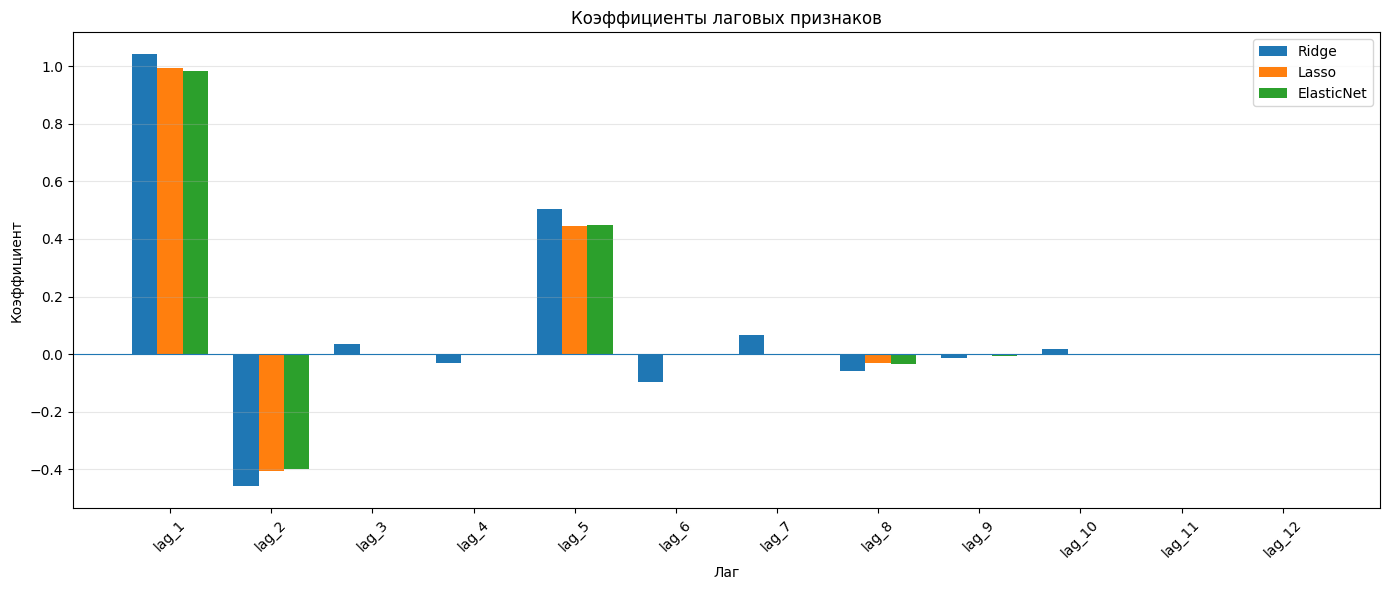

Истинно используемые лаги: lag_1, lag_2, lag_5
Ridge: lag_1, lag_2, lag_3, lag_4, lag_5, lag_6, lag_7, lag_8, lag_9, lag_10, lag_11, lag_12
Lasso: lag_1, lag_2, lag_5, lag_8
ElasticNet: lag_1, lag_2, lag_5, lag_8, lag_9, lag_10


In [7]:
x = np.arange(len(lag_names))
width = 0.25

plt.figure(figsize=(14, 6))

plt.bar(
    x - width,
    coef_table["Ridge"],
    width=width,
    label="Ridge"
)

plt.bar(
    x,
    coef_table["Lasso"],
    width=width,
    label="Lasso"
)

plt.bar(
    x + width,
    coef_table["ElasticNet"],
    width=width,
    label="ElasticNet"
)

plt.axhline(0, linewidth=0.8)
plt.xticks(x, lag_names, rotation=45)
plt.xlabel("Лаг")
plt.ylabel("Коэффициент")
plt.title("Коэффициенты лаговых признаков")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Истинно используемые лаги: lag_1, lag_2, lag_5")

for name in ["Ridge", "Lasso", "ElasticNet"]:
    selected = coef_table.index[
        np.abs(coef_table[name]) > 1e-4
    ].tolist()

    print(
        f"{name}: {', '.join(selected)}"
    )

### Вывод по заданию 3

Ridge уменьшает коэффициенты, но практически не выполняет отбор признаков, поэтому сохраняет большинство лагов. Lasso создаёт наиболее разреженную модель и стремится оставить небольшое число лагов. Elastic Net сочетает L1- и L2-регуляризацию и обычно сохраняет несколько связанных лагов, оставаясь устойчивее при коррелированных признаках.

Для временных рядов особенно важно использовать последовательное разделение данных и `TimeSeriesSplit`, поскольку случайное перемешивание может привести к утечке информации из будущего.

# Общий вывод по варианту №7

В первой части показано, что Ridge может стабилизировать коэффициенты линейной модели, однако регуляризация не гарантирует автоматического устранения гетероскедастичности. Поэтому остатки необходимо анализировать отдельно.

Во второй части Lasso продемонстрировал компромисс между разреженностью и качеством отбора: при росте `alpha` FDR уменьшается, но слишком сильная регуляризация снижает полноту обнаружения истинных признаков.

В третьей части показано различие методов на коррелированных лаговых признаках временного ряда. Ridge сохраняет плотную модель, Lasso делает наиболее жёсткий отбор, а Elastic Net занимает промежуточное положение и сочетает разреженность с групповым эффектом.

# Источники

1. Hastie, T., Tibshirani, R., Friedman, J. *The Elements of Statistical Learning*. 2nd ed., 2009.
2. Tibshirani, R. Regression Shrinkage and Selection via the Lasso. *Journal of the Royal Statistical Society: Series B*, 1996.
3. Zou, H., Hastie, T. Regularization and Variable Selection via the Elastic Net. *Journal of the Royal Statistical Society: Series B*, 2005.
4. Pedregosa, F. et al. Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 2011.